## Treinando o Modelo

In [22]:
#Importações

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, PolynomialFeatures, PowerTransformer, RobustScaler, StandardScaler,
QuantileTransformer)

from joblib import dump

from apoio.config import DADOS_LIMPOS, MODELO_FINAL
from apoio.auxiliares import dataframe_coeficientes
from apoio.graficos import (plot_coeficientes, plot_comparar_metricas_modelos, plot_residuos_estimador)
from apoio.modelos import (organiza_resultados, treinar_e_validar_modelo_regressao, grid_search_cv_regressor)

import warnings
warnings.filterwarnings("ignore")

#### Checagens básicas da base

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41,880,129,322,126,8.3252,452600,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.26,37.84,42,2555,665,1206,595,2.0804,226700,NEAR BAY,2,4.294118,2.026891,0.260274
3,-122.26,37.85,50,1120,283,697,264,2.1250,140000,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.26,37.84,50,2239,455,990,419,1.9911,158700,NEAR BAY,2,5.343675,2.362768,0.203216


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17564 entries, 0 to 17563
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17564 non-null  float64 
 1   latitude                  17564 non-null  float64 
 2   housing_median_age        17564 non-null  int8    
 3   total_rooms               17564 non-null  int16   
 4   total_bedrooms            17564 non-null  int16   
 5   population                17564 non-null  int16   
 6   households                17564 non-null  int16   
 7   median_income             17564 non-null  float64 
 8   median_house_value        17564 non-null  int32   
 9   ocean_proximity           17564 non-null  category
 10  median_income_cat         17564 non-null  int64   
 11  rooms_per_household       17564 non-null  float64 
 12  population_per_household  17564 non-null  float64 
 13  bedrooms_per_room         17564 non-null  floa

#### Definindo:

- Target (coluna alvo)
- Coluna do one hot encoder
- Coluna do ordinal encoder
- Colunas do robust scaler

#### Como saber quais colunas se aplicam?

- **One Hot Encoder:** usado quando os valores não têm hierarquia.
- **OrdinalEncoder:** usado quando existe hierarquia clara.
- **RobustScaler:** usado em variáveis numéricas, principalmente quando tem valores extremos (outliers).

In [6]:
coluna_target = ["median_house_value"]
coluna_one_hot_encoder = ["ocean_proximity"]
coluna_ordinal_encoder = ["median_income_cat"]

In [8]:
colunas_robust_scaler = df.columns.difference(coluna_target + coluna_one_hot_encoder + coluna_ordinal_encoder)
colunas_robust_scaler

Index(['bedrooms_per_room', 'households', 'housing_median_age', 'latitude',
       'longitude', 'median_income', 'population', 'population_per_household',
       'rooms_per_household', 'total_bedrooms', 'total_rooms'],
      dtype='object')

#### Aplicando RobustScaler e PolynomialFeatures nas colunas numéricas

In [9]:
pipeline_robust_scaler = Pipeline(steps=[("robust_scaler", RobustScaler()), ("poly", PolynomialFeatures(degree=1, include_bias=False))])

**RobustScaler** vai normalizar os dados usando mediana e IQR (Intervalo Interquartil), diminuir o impacto de outliers.

**PolynomialFeatures** retorna as mesmas colunas.

#### Criando um pipeline que aplica transformações diferentes em colunas diferentes

In [11]:
preprocessamento = ColumnTransformer(transformers=[("ordinal_encoder", OrdinalEncoder(categories="auto"), coluna_ordinal_encoder),
                                                   ("one_hot", OneHotEncoder(drop="first"), coluna_one_hot_encoder),
                                                   ("robust_scaler_poly", pipeline_robust_scaler, colunas_robust_scaler)])

**OrdinalEncoder** transforma categorias com ordem em números.

**OneHotEncoder** cria colunas binárias (0 ou 1).

#### Definindo X e y para serem usados posteriormente

In [13]:
X = df.drop(columns=coluna_target)
y = df[coluna_target]

In [14]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41,880,129,322,126,8.3252,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.26,37.84,42,2555,665,1206,595,2.0804,NEAR BAY,2,4.294118,2.026891,0.260274
3,-122.26,37.85,50,1120,283,697,264,2.1250,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.26,37.84,50,2239,455,990,419,1.9911,NEAR BAY,2,5.343675,2.362768,0.203216


In [15]:
y.head()

,median_house_value
0,452600
1,358500
2,226700
3,140000
4,158700


#### Criando o conjunto de hiperparâmetros que o GridSearch vai testar automaticamente

In [16]:
param_grid = {
    "regressor__preprocessor__robust_scaler_poly__poly__degree": [1, 2, 3],
    "regressor__reg__alpha": [1E-2, 5E-2, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0],
}

#### Criando o GridSearch

In [20]:
grid_search = grid_search_cv_regressor(regressor=Ridge(), param_grid=param_grid, preprocessor=preprocessamento,
                                       target_transformer=QuantileTransformer(output_distribution="normal"))

grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('robust_scaler_poly',
                                                                                                              Pipeline(steps=[('robust_scaler',
                                                                                                                               Ro...
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__preprocessor__robust_scaler_poly__poly__degree': [1,
                                                                                       2,
                                                                                       3],
                         'regressor__reg__alpha': [0.01, 0.05, 0.1, 0.25, 0.5,
                                                   1.0, 2.0, 5.0, 10.0, 20.0,
                                                   50.0]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

O que o **GridSearch** faz?

Testa as combinações, avalia elas com validação cruzada e escolhe a melhor

In [23]:
grid_search.fit(X, y)

Fitting 5 folds for each of 33 candidates, totalling 165 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('robust_scaler_poly',
                                                                                                              Pipeline(steps=[('robust_scaler',
                                                                                                                               Ro...
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__preprocessor__robust_scaler_poly__poly__degree': [1,
                                                                                       2,
                                                                                       3],
                         'regressor__reg__alpha': [0.01, 0.05, 0.1, 0.25, 0.5,
                                                   1.0, 2.0, 5.0, 10.0, 20.0,
                                                   50.0]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

O que o **.fit()** faz?

Treina o modelo que o GridSearch escolheu como melhor.

#### Checando os melhores parâmetros e o melhor score

In [25]:
grid_search.best_params_

{'regressor__preprocessor__robust_scaler_poly__poly__degree': 3,
 'regressor__reg__alpha': 10.0}

In [26]:
grid_search.best_score_

np.float64(-50463.55458850091)

#### Criando um DataFrame com os coeficientes do melhor modelo

In [29]:
coeficientes = dataframe_coeficientes(grid_search.best_estimator_.regressor_["reg"].coef_,
                                      grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out())

coeficientes

,coeficiente
robust_scaler_poly__longitude,-1.028139
robust_scaler_poly__latitude,-0.960706
one_hot__ocean_proximity_INLAND,-0.467049
robust_scaler_poly__latitude longitude population_per_household,-0.416878
robust_scaler_poly__population_per_household,-0.332774
...,...
robust_scaler_poly__latitude^2 longitude,0.248838
robust_scaler_poly__latitude median_income population_per_household,0.249566
robust_scaler_poly__housing_median_age median_income,0.249934
robust_scaler_poly__bedrooms_per_room,0.339926


#### Gráfico dos coeficientes

Existem uma quantidade de coeficientes muito grande, então faremos um filtro de coefientes no intervalo de -0.2 e 0.2, que são diferentes de 0.

In [31]:
coeficientes[coeficientes["coeficiente"].between(-0.2, 0.2) & coeficientes["coeficiente"]!=0]

,coeficiente
one_hot__ocean_proximity_NEAR BAY,-0.199939
robust_scaler_poly__housing_median_age population_per_household total_bedrooms,-0.199019
robust_scaler_poly__longitude median_income,-0.186987
robust_scaler_poly__households median_income^2,-0.186413
robust_scaler_poly__bedrooms_per_room rooms_per_household,-0.180816
...,...
robust_scaler_poly__total_bedrooms,0.170450
robust_scaler_poly__bedrooms_per_room rooms_per_household total_bedrooms,0.172903
robust_scaler_poly__median_income population rooms_per_household,0.176377
robust_scaler_poly__median_income population population_per_household,0.177365


A quantidade de coeficientes ainda é muito grande, então o gráfico será feito com os coeficientes que não entram no filtro anterior.

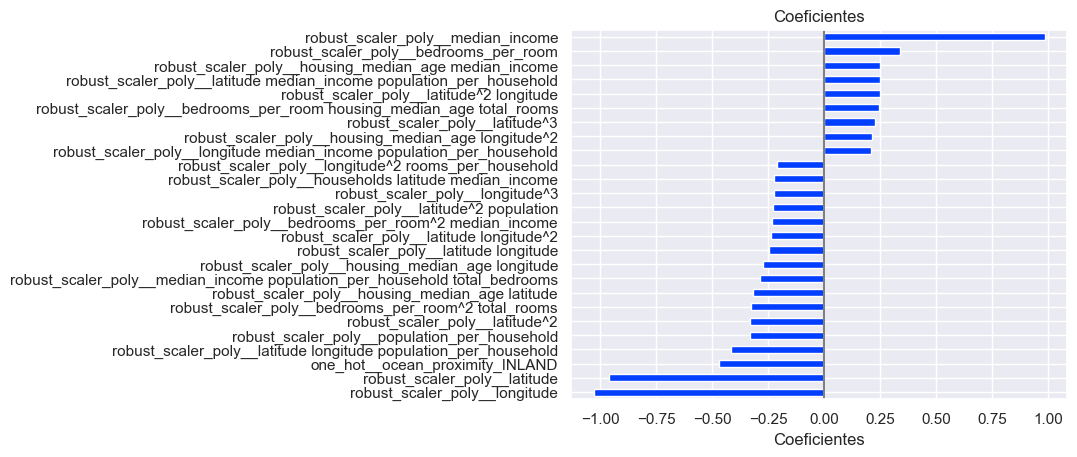

In [36]:
plot_coeficientes(coeficientes[~coeficientes["coeficiente"].between(-0.2, 0.2)])